1️⃣ Fetch Data From Coin Gecko API

In [50]:
import requests

def extract_bitcoin_data():

    url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

    params = {
        "vs_currency": "usd",
        "days": "360"
    }

    response = requests.get(url, params=params)
    data = response.json()

    return data

2️⃣ Transform Data

In [51]:
import pandas as pd

def transform_bitcoin_data(data):
    # 1.RETRIEVE DATA from JSON
    prices = data["prices"]           
    market_caps = data["market_caps"] 
    volumes = data["total_volumes"]   

    # 2.Converting list to DataFrame
    df_prices = pd.DataFrame(prices, columns=["timestamp", "price"])
    df_marketcap = pd.DataFrame(market_caps, columns=["timestamp", "market_cap"])
    df_volume = pd.DataFrame(volumes, columns=["timestamp", "volume"])

    # 3.Combining tables
    df = df_prices.merge(df_marketcap, on="timestamp")
    df = df.merge(df_volume, on="timestamp")

    # 4.Convert timestamp to date
    df["date"] = pd.to_datetime(df["timestamp"], unit="ms")

    # 5.Select the column you want to use
    df = df[[
        "date",
        "price",
        "market_cap",
        "volume"
    ]]

    # 6.Sort data
    df = df.sort_values("date").reset_index(drop=True)

    return df

3️⃣ Show Data

In [52]:
data = extract_bitcoin_data()
df = transform_bitcoin_data(data)

pd.concat([df.head(), df.tail()])

,date,price,market_cap,volume
0,2025-03-20 00:00:00,86815.441095,1.721565e+12,3.387122e+10
1,2025-03-21 00:00:00,84270.843590,1.672551e+12,2.757913e+10
2,2025-03-22 00:00:00,84009.532918,1.666749e+12,1.809100e+10
3,2025-03-23 00:00:00,83793.308542,1.662574e+12,7.771135e+09
4,2025-03-24 00:00:00,85787.709149,1.702010e+12,1.261759e+10
356,2026-03-11 00:00:00,69883.008876,1.397516e+12,5.703132e+10
357,2026-03-12 00:00:00,70226.818791,1.405229e+12,4.818868e+10
358,2026-03-13 00:00:00,70544.425355,1.411413e+12,4.309338e+10
359,2026-03-14 00:00:00,70965.282286,1.419133e+12,6.232826e+10
360,2026-03-14 10:49:31,70533.604581,1.410774e+12,5.150569e+10


In [53]:
len(df)

361

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        361 non-null    datetime64[ns]
 1   price       361 non-null    float64       
 2   market_cap  361 non-null    float64       
 3   volume      361 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 11.4 KB


4️⃣ Visualization

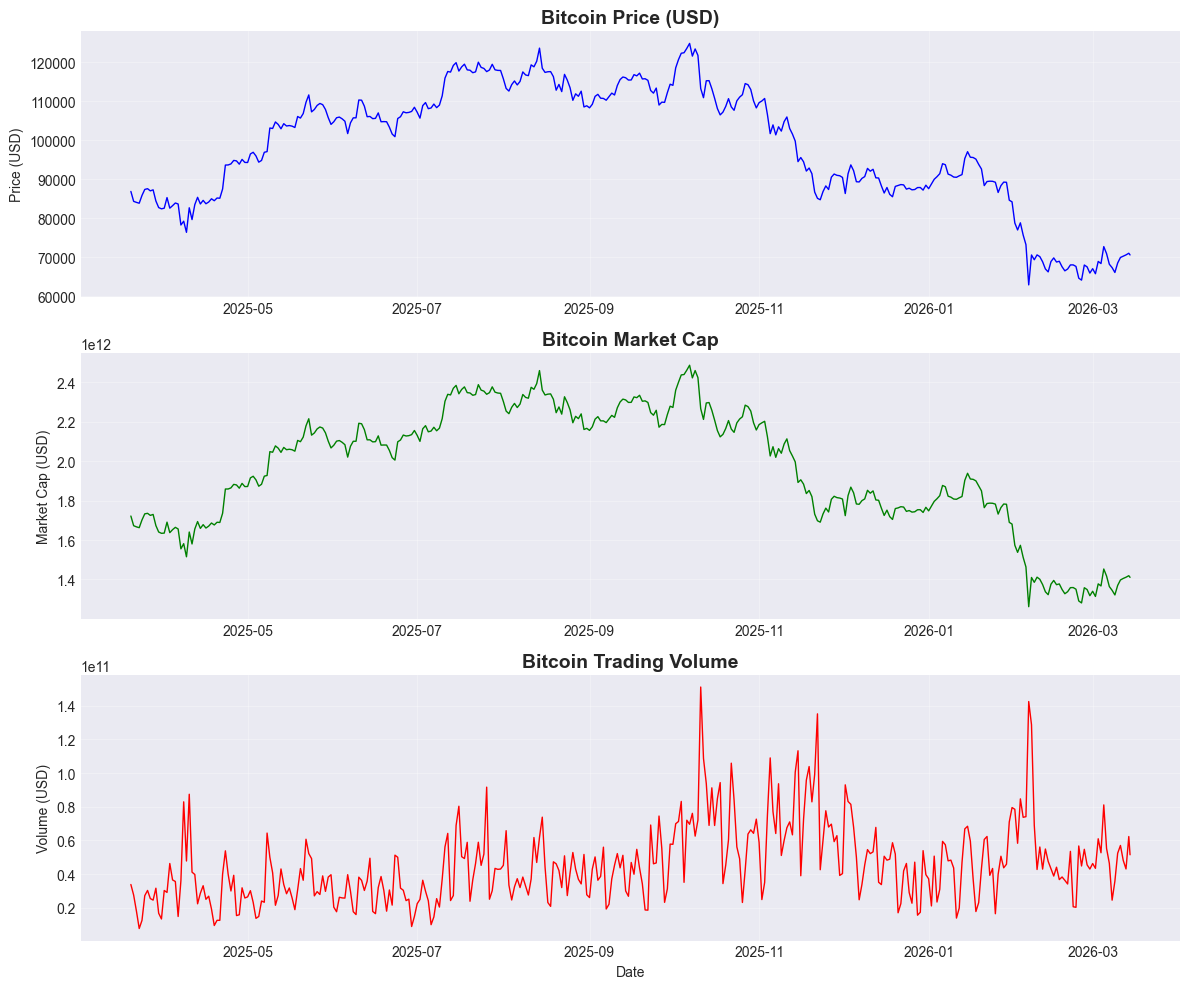


📊 BITCOIN STATISTICS (Last 360 days):
📈 Highest price: $124,773.51
📉 Lowest price: $62,853.69
📊 Average price: $98,328.11
💰 Current price: $70,533.60
📅 Period: 2025-03-20 to 2026-03-14
📦 Total data points: 361


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_data(df):
    """
    Membuat visualisasi data Bitcoin
    """
    # Style
    plt.style.use('seaborn-v0_8-darkgrid')
    
    # Create a figure with 3 subplots
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Plot 1: Price
    axes[0].plot(df['date'], df['price'], color='blue', linewidth=1)
    axes[0].set_title('Bitcoin Price (USD)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Price (USD)')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Market Cap
    axes[1].plot(df['date'], df['market_cap'], color='green', linewidth=1)
    axes[1].set_title('Bitcoin Market Cap', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Market Cap (USD)')
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Volume
    axes[2].plot(df['date'], df['volume'], color='red', linewidth=1)
    axes[2].set_title('Bitcoin Trading Volume', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Volume (USD)')
    axes[2].set_xlabel('Date')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print("\n📊 BITCOIN STATISTICS (Last 360 days):")
    print(f"📈 Highest price: ${df['price'].max():,.2f}")
    print(f"📉 Lowest price: ${df['price'].min():,.2f}")
    print(f"📊 Average price: ${df['price'].mean():,.2f}")
    print(f"💰 Current price: ${df['price'].iloc[-1]:,.2f}")
    print(f"📅 Period: {df['date'].min().date()} to {df['date'].max().date()}")
    print(f"📦 Total data points: {len(df)}")

# Visualisasi
visualize_data(df)

LOAD DATA TO DATABASE

In [56]:
from sqlalchemy import create_engine

username = "postgres"
password = "RezaReza"
host = "localhost"
port = "5432"
database = "crypto_pipeline"

engine = create_engine(
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

def load_to_postgres(df):
    df.to_sql(
        name="bitcoin_market",
        con=engine,
        if_exists="replace",
        index=False
    )
    print("Data successfully entered into the database")
    

In [57]:
# Retrieve data
data = extract_bitcoin_data()
df = transform_bitcoin_data(data)

# Load Function!
load_to_postgres(df)

Data successfully entered into the database


Save Data

In [58]:
#CSV
import os

os.makedirs("data", exist_ok=True)
df.to_csv("data/bitcoin_market.csv", index=False)
print("✅ Successfully")

✅ Successfully


In [59]:
# From Database To Excel File
df = pd.read_sql("SELECT * FROM bitcoin_market", engine)

df.to_excel("data/bitcoin_market_export.xlsx", index=False)
print("✅ Saved as Excel")

✅ Saved as Excel
